# LST Retrieval from Landsat 8

## Objective

The objective of this notebook is to understand and implement the initial
Land Surface Temperature (LST) retrieval workflow using Landsat 8
Collection 2 Level-2 data.

The workflow will begin with inspection of the satellite data and will
progress through radiometric preprocessing, spectral index calculation,
emissivity estimation, and LST retrieval.

## Study Area

Lucknow, Uttar Pradesh, India

## Satellite Data

Landsat 8 OLI/TIRS
Collection 2 Level 2

## Workflow

The workflow implemented in this notebook consists of the following steps:

1. Load the Landsat 8 Collection 2 Level-2 scene.
2. Inspect raster dimensions, spatial resolution, CRS, NoData values, and data types.
3. Read the Landsat metadata (MTL) file.
4. Extract Level-2 Surface Reflectance parameters explicitly from the
   `LEVEL2_SURFACE_REFLECTANCE_PARAMETERS` metadata group.
5. Identify the Landsat Red (`SR_B4`) and Near-Infrared (`SR_B5`) bands.
6. Load the Lucknow city boundary and transform it to the CRS of the Landsat scene.
7. Clip the Red and NIR bands to the Lucknow study area.
8. Convert the stored Level-2 values of B4 and B5 to surface reflectance
   using the corresponding scale factors and additive offsets.
9. Calculate the Normalized Difference Vegetation Index (NDVI).
10. Load the Landsat thermal Surface Temperature band (`ST_B10`).
11. Extract the Level-2 Surface Temperature scaling parameters.
12. Clip and convert the thermal data to Land Surface Temperature.
13. Convert temperature from Kelvin to degrees Celsius.
14. Apply appropriate quality masking to remove invalid observations.
15. Visualize and validate the resulting LST and NDVI rasters.


### Spatial Resolution

- Reflective bands: 30 m
- Thermal band: provided on the Level-2 30 m product grid

### Bands Used

| Band | Product | Purpose |
|------|---------|---------|
| B3 | SR_B3 | Green / MNDWI |
| B4 | SR_B4 | Red / NDVI |
| B5 | SR_B5 | NIR / NDVI |
| B6 | SR_B6 | SWIR / NDBI |
| B10 | ST_B10 | Land Surface Temperature |

## Expected Output

The notebook is expected to produce the following outputs:

- Validated Landsat 8 Level-2 raster information, including CRS,
  spatial resolution, dimensions, data type, and NoData value.
- A Lucknow city boundary aligned with the Landsat coordinate reference system.
- A clipped Red reflectance raster derived from `SR_B4`.
- A clipped Near-Infrared reflectance raster derived from `SR_B5`.
- An NDVI raster representing the spatial distribution of vegetation
  across Lucknow.
- A clipped thermal Surface Temperature raster derived from `ST_B10`.
- A Land Surface Temperature raster in degrees Celsius.
- Statistical summaries of NDVI and LST, including minimum, maximum,
  and mean values.
- Visual maps of NDVI and LST for the Lucknow study area.

In [128]:
import rasterio

In [129]:
import sys #to verufy python environment is in use

print(sys.executable)

d:\Projects\GeoAI-LST-Downscaling\.venv\Scripts\python.exe


In [130]:
print(rasterio.__version__) #to verify rasterio version is correct

1.5.0


#### 1.Loading Landsat data

In [131]:
from pathlib import Path #load the Path module to handle file paths

project_root = Path.cwd().parent

landsat_folder = project_root / "data" / "raw" / "landsat" #locate the Landsat folder in the project directory

print(landsat_folder)

d:\Projects\GeoAI-LST-Downscaling\data\raw\landsat


In [132]:
print(list(landsat_folder.iterdir()))  #list all files in the Landsat folder

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_ANG.txt'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_MTL.json'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_MTL.txt'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_MTL.xml'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_QA_PIXEL.TIF'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_QA_RADSAT.TIF'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_SR_B1.TIF'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_SR_B2.TIF'), WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw

#### 2. Inspect raster dimensions, spatial resolution, CRS, NoData values, and data types.

In [133]:
landsat_files = list(landsat_folder.rglob("*.tif")) 
for landsat_file in landsat_files:
    print(landsat_file.name)
    with rasterio.open(landsat_file) as src: 
        print("Width:", src.width)
        print("Height:", src.height)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

LC08_L2SP_144041_20260519_20260528_02_T1_QA_PIXEL.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: None
Data type: uint16
LC08_L2SP_144041_20260519_20260528_02_T1_QA_RADSAT.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: None
Data type: uint16
LC08_L2SP_144041_20260519_20260528_02_T1_SR_B1.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16
LC08_L2SP_144041_20260519_20260528_02_T1_SR_B2.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16
LC08_L2SP_144041_20260519_20260528_02_T1_SR_B3.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16
LC08_L2SP_144041_20260519_20260528_02_T1_SR_B4.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16
LC08_L2SP_144041_20260519_20260528_02_T1_SR_B5.TIF
Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0

#### 3. Read the Landsat metadata (MTL) file.

In [134]:
mtl_files = list(landsat_folder.rglob("*_MTL.txt"))

print(mtl_files) #print the list of MTL files found in the Landsat folder and its subfolders

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_MTL.txt')]


In [135]:
mtl_path = mtl_files[0]

print(mtl_path)  #print the name of the first MTL file found

d:\Projects\GeoAI-LST-Downscaling\data\raw\landsat\LC08_L2SP_144041_20260519_20260528_02_T1_MTL.txt


#### 4. Extract Level-2 Surface Reflectance parameters explicitly from the
   `LEVEL2_SURFACE_REFLECTANCE_PARAMETERS` metadata group.

In [136]:
with open(mtl_path, "r") as f:
    mtl_text = f.read()

for line in mtl_text.splitlines():
    if "REFLECTANCE_MULT" in line or "REFLECTANCE_ADD" in line:
        print(line) #print the lines containing REFLECTANCE_MULT and REFLECTANCE_ADD from the MTL file

    REFLECTANCE_MULT_BAND_1 = 2.75e-05
    REFLECTANCE_MULT_BAND_2 = 2.75e-05
    REFLECTANCE_MULT_BAND_3 = 2.75e-05
    REFLECTANCE_MULT_BAND_4 = 2.75e-05
    REFLECTANCE_MULT_BAND_5 = 2.75e-05
    REFLECTANCE_MULT_BAND_6 = 2.75e-05
    REFLECTANCE_MULT_BAND_7 = 2.75e-05
    REFLECTANCE_ADD_BAND_1 = -0.2
    REFLECTANCE_ADD_BAND_2 = -0.2
    REFLECTANCE_ADD_BAND_3 = -0.2
    REFLECTANCE_ADD_BAND_4 = -0.2
    REFLECTANCE_ADD_BAND_5 = -0.2
    REFLECTANCE_ADD_BAND_6 = -0.2
    REFLECTANCE_ADD_BAND_7 = -0.2
    REFLECTANCE_MULT_BAND_1 = 2.0000E-05
    REFLECTANCE_MULT_BAND_2 = 2.0000E-05
    REFLECTANCE_MULT_BAND_3 = 2.0000E-05
    REFLECTANCE_MULT_BAND_4 = 2.0000E-05
    REFLECTANCE_MULT_BAND_5 = 2.0000E-05
    REFLECTANCE_MULT_BAND_6 = 2.0000E-05
    REFLECTANCE_MULT_BAND_7 = 2.0000E-05
    REFLECTANCE_MULT_BAND_8 = 2.0000E-05
    REFLECTANCE_MULT_BAND_9 = 2.0000E-05
    REFLECTANCE_ADD_BAND_1 = -0.100000
    REFLECTANCE_ADD_BAND_2 = -0.100000
    REFLECTANCE_ADD_BAND_3 = -0.100000
   

#### 5. Identify the Landsat Red (`SR_B4`) and Near-Infrared (`SR_B5`) bands.

In [137]:
red_files = list(landsat_folder.rglob("*_SR_B4.TIF"))  #finding all files that match the pattern *_SR_B4.TIF in the Landsat folder and its subfolders

print(red_files)

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_SR_B4.TIF')]


In [138]:
red_path = red_files[0]

print(red_path)

d:\Projects\GeoAI-LST-Downscaling\data\raw\landsat\LC08_L2SP_144041_20260519_20260528_02_T1_SR_B4.TIF


In [139]:
with rasterio.open(red_path) as src:  #opening the first red band file using rasterio
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16


In [140]:
with rasterio.open(red_path) as src:
    red = src.read(1)

print("Shape:", red.shape)
print("Minimum:", red.min())
print("Maximum:", red.max())
print("First 10 values:", red.flatten()[:10])  #load the first 10 values of the red band array

Shape: (7801, 7651)
Minimum: 0
Maximum: 39031
First 10 values: [0 0 0 0 0 0 0 0 0 0]


In [141]:
import numpy as np

valid_red = red[red != 0]  #find the valid pixels in the red band array by filtering out the pixels with a value of 0

print("Valid pixels:", valid_red.size)
print("Minimum valid value:", valid_red.min())
print("Maximum valid value:", valid_red.max())
print("Mean stored value:", valid_red.mean())

Valid pixels: 40524113
Minimum valid value: 7828
Maximum valid value: 39031
Mean stored value: 12026.098456565847


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))


In [142]:
nir_files = list(landsat_folder.rglob("*_SR_B5.TIF"))  #finding all files that match the pattern *_SR_B5.TIF in the Landsat folder and its subfolders

print(nir_files)

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_SR_B5.TIF')]


In [143]:
nir_path = nir_files[0]

print(nir_path)

d:\Projects\GeoAI-LST-Downscaling\data\raw\landsat\LC08_L2SP_144041_20260519_20260528_02_T1_SR_B5.TIF


In [144]:
with rasterio.open(nir_path) as src:  #opening the first nir band file using rasterio
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16


In [145]:
import numpy as np

valid_nir = nir[nir != 0]  #find the valid pixels in the nir band array by filtering out the pixels with a value of 0

print("Valid pixels:", valid_nir.size)
print("Minimum valid value:", valid_nir.min())
print("Maximum valid value:", valid_nir.max())
print("Mean stored value:", valid_nir.mean())

Valid pixels: 40524113
Minimum valid value: 10340
Maximum valid value: 50874
Mean stored value: 17773.92442620521


#### 6. Load the Lucknow city boundary and transform it to the CRS of the Landsat scene.

In [146]:
import geopandas as gpd
boundary_path = (
    project_root
    / "data"
    / "raw"
    / "boundary"
    / "Lucknow_city_boundary.geojson"
)

lucknow = gpd.read_file(boundary_path)

print(lucknow)
print("CRS:", lucknow.crs)

   id                                           geometry
0   1  POLYGON ((80.84284 26.76833, 80.8471 26.77277,...
CRS: EPSG:4326


In [147]:
print("Number of features:", len(lucknow))
print("Geometry type:", lucknow.geometry.geom_type.unique())
print("CRS:", lucknow.crs)

Number of features: 1
Geometry type: <StringArray>
['Polygon']
Length: 1, dtype: str
CRS: EPSG:4326


In [148]:
lucknow = lucknow.to_crs("EPSG:32644")

print("Lucknow CRS:", lucknow.crs)

Lucknow CRS: EPSG:32644


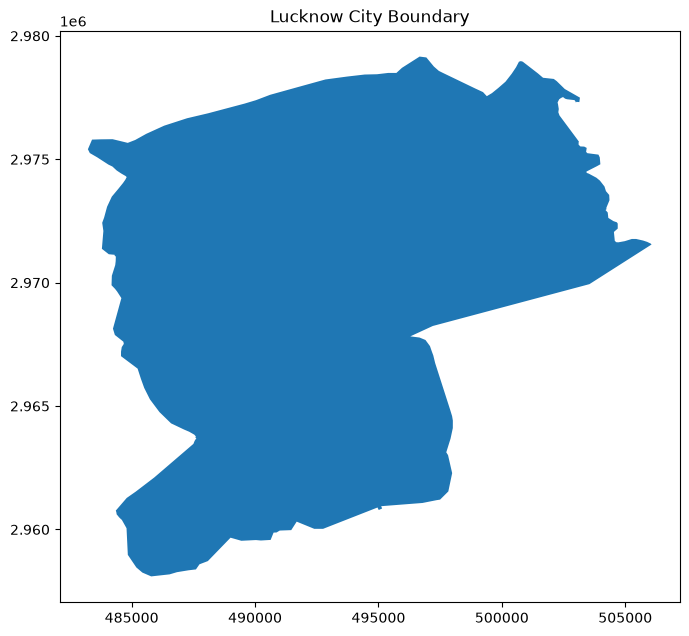

In [149]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))

lucknow.plot(ax=ax)

ax.set_title("Lucknow City Boundary")
plt.show()

#### 7. Clip the Red and NIR bands to the Lucknow study area.

In [150]:
from rasterio.mask import mask

with rasterio.open(red_path) as src:
    red_lucknow, red_transform = mask(
        src,
        lucknow.geometry,
        crop=True,
        nodata=0
    )

red_lucknow = red_lucknow[0]

print("Original B4:", red.shape)
print("Lucknow B4:", red_lucknow.shape)

Original B4: (7801, 7651)
Lucknow B4: (703, 762)


Plotting Lucknow Area with RED Reflectance

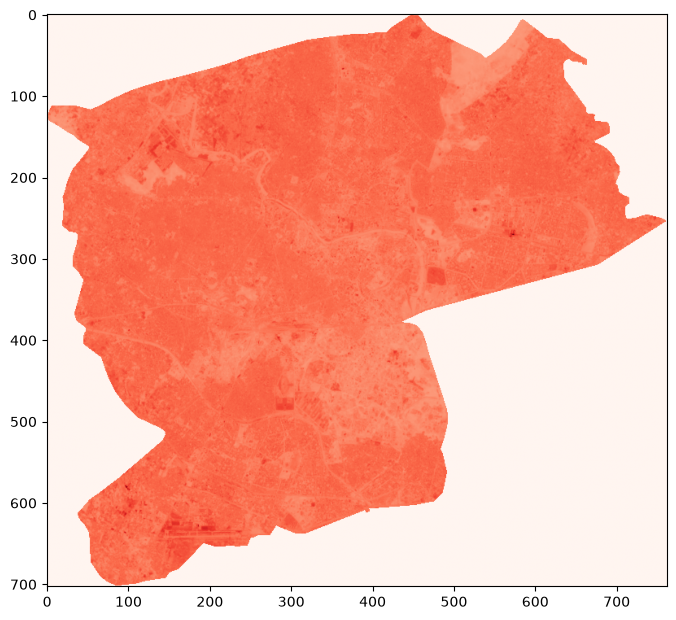

In [151]:
plt.figure(figsize=(8, 8))
plt.imshow(red_lucknow, cmap="Reds")

In [152]:
with rasterio.open(nir_path) as src:
    nir_lucknow, nir_transform = mask(
        src,
        lucknow.geometry,
        crop=True,
        nodata=0
    )

nir_lucknow = nir_lucknow[0]

print("Original B5:", nir.shape)
print("Lucknow NIR:", nir_lucknow.shape)

Original B5: (7801, 7651)
Lucknow NIR: (703, 762)


Plotting  the Lucknow Area with NIR Reflectance

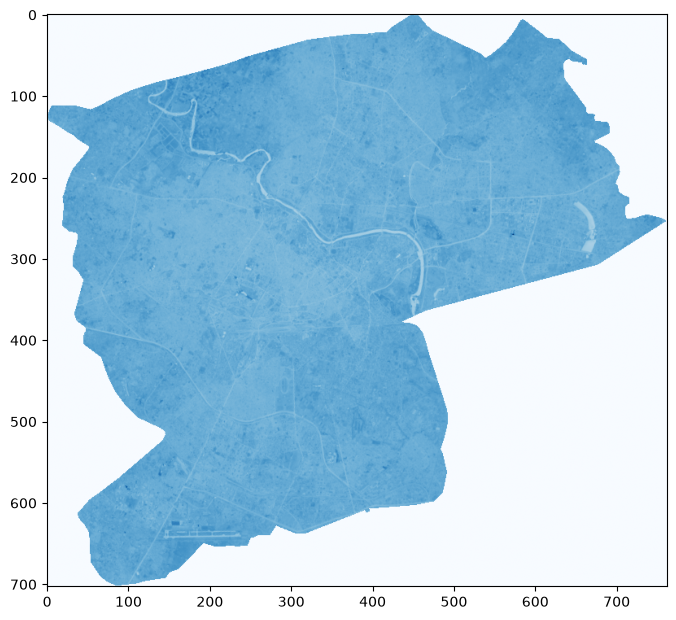

In [153]:
plt.figure(figsize=(8, 8))
plt.imshow(nir_lucknow, cmap="Blues")

In [154]:
print(red_lucknow.shape)
print(nir_lucknow.shape)

(703, 762)
(703, 762)


#### 8. Convert the stored Level-2 values of B4 and B5 to surface reflectance using the corresponding scale factors and additive offsets.

Extracting Required Data From MTL File for Band 4

In [155]:
level2_group = "LEVEL2_SURFACE_REFLECTANCE_PARAMETERS"
level2_block = extract_mtl_group(mtl_text, level2_group)
level2_params = parse_mtl_block(level2_block)

# Example values
for key in ["REFLECTANCE_MULT_BAND_4", "REFLECTANCE_ADD_BAND_4"]:
    print(f"{key}: {level2_params.get(key)}")

REFLECTANCE_MULT_BAND_4: 2.75e-05
REFLECTANCE_ADD_BAND_4: -0.2


Calculating RED reflectance value (Band 4)

In [156]:
import numpy as np


reflectance_mult = float(level2_params.get("REFLECTANCE_MULT_BAND_4", 0))
reflectance_add = float(level2_params.get("REFLECTANCE_ADD_BAND_4", 0))
red_reflectance = (
    red.astype(np.float32) * reflectance_mult
    + reflectance_add
)

In [157]:
print("Minimum:", np.nanmin(red_reflectance))
print("Maximum:", np.nanmax(red_reflectance))
print("Mean:", np.nanmean(red_reflectance))

Minimum: -0.2
Maximum: 0.87335247
Mean: 0.024544522


In [158]:
row = 2000
col = 2000

stored_value = red[row, col]
calculated_value = red_reflectance[row, col]

print("Stored B4 value:", stored_value)
print("Calculated reflectance:", calculated_value)

Stored B4 value: 13602
Calculated reflectance: 0.174055


Plotting the RED Reflectance

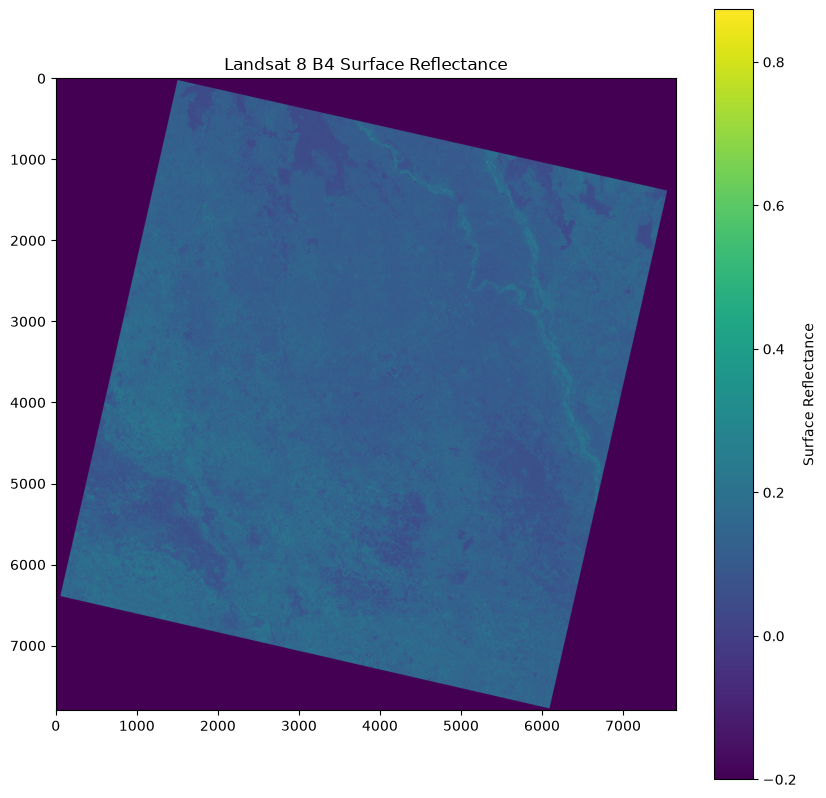

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

plt.imshow(red_reflectance)

plt.title("Landsat 8 B4 Surface Reflectance")
plt.colorbar(label="Surface Reflectance")

plt.show()

In [160]:
red_lucknow_reflectance = (
    red_lucknow.astype(np.float32) * reflectance_mult
    + reflectance_add
)

In [161]:
red_lucknow_reflectance[red_lucknow == 0] = np.nan

In [162]:
print("Minimum:", np.nanmin(red_lucknow_reflectance))
print("Maximum:", np.nanmax(red_lucknow_reflectance))
print("Mean:", np.nanmean(red_lucknow_reflectance))

Minimum: 0.041999996
Maximum: 0.49580503
Mean: 0.1342496


Plotting the RED Reflectance of Lucknow Area

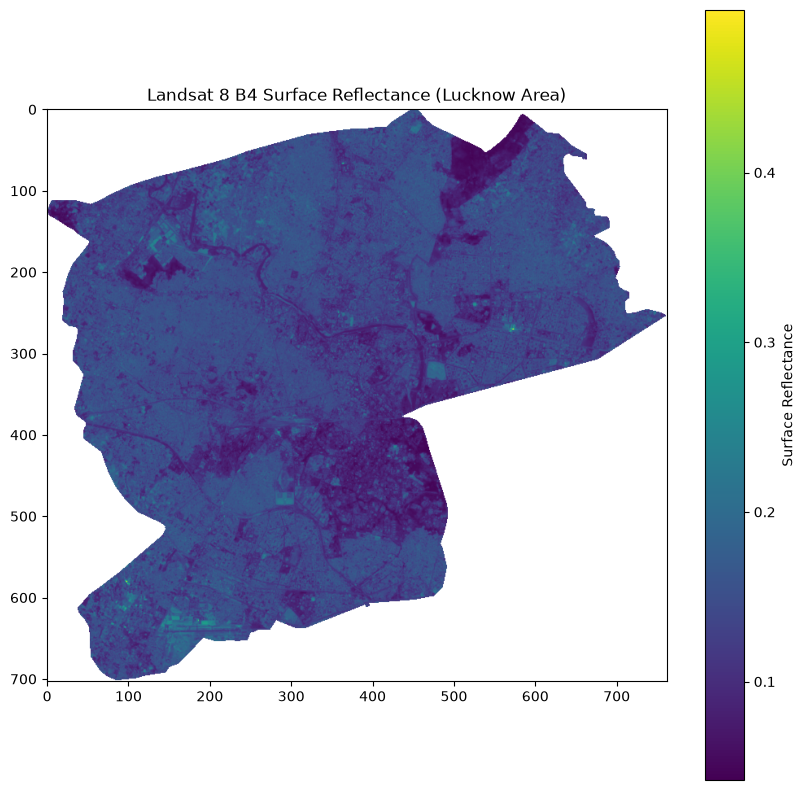

In [163]:
plt.figure(figsize=(10, 10))

plt.imshow(red_lucknow_reflectance)

plt.title("Landsat 8 B4 Surface Reflectance (Lucknow Area)")
plt.colorbar(label="Surface Reflectance")

plt.show()

Extracting Required Data from MTL File for Band 5

In [164]:
level2_group = "LEVEL2_SURFACE_REFLECTANCE_PARAMETERS"
level2_block = extract_mtl_group(mtl_text, level2_group)
level2_params = parse_mtl_block(level2_block)

for key in ["REFLECTANCE_MULT_BAND_5", "REFLECTANCE_ADD_BAND_5"]:
    print(f"{key}: {level2_params.get(key)}")

REFLECTANCE_MULT_BAND_5: 2.75e-05
REFLECTANCE_ADD_BAND_5: -0.2


Calculating NIR Reflectance Value (Band 5)

In [165]:
import numpy as np


reflectance_mult = float(level2_params.get("REFLECTANCE_MULT_BAND_4", 0))
reflectance_add = float(level2_params.get("REFLECTANCE_ADD_BAND_4", 0))
nir_reflectance = (
    nir.astype(np.float32) * reflectance_mult
    + reflectance_add
)

Plotting the NIR Reflectance

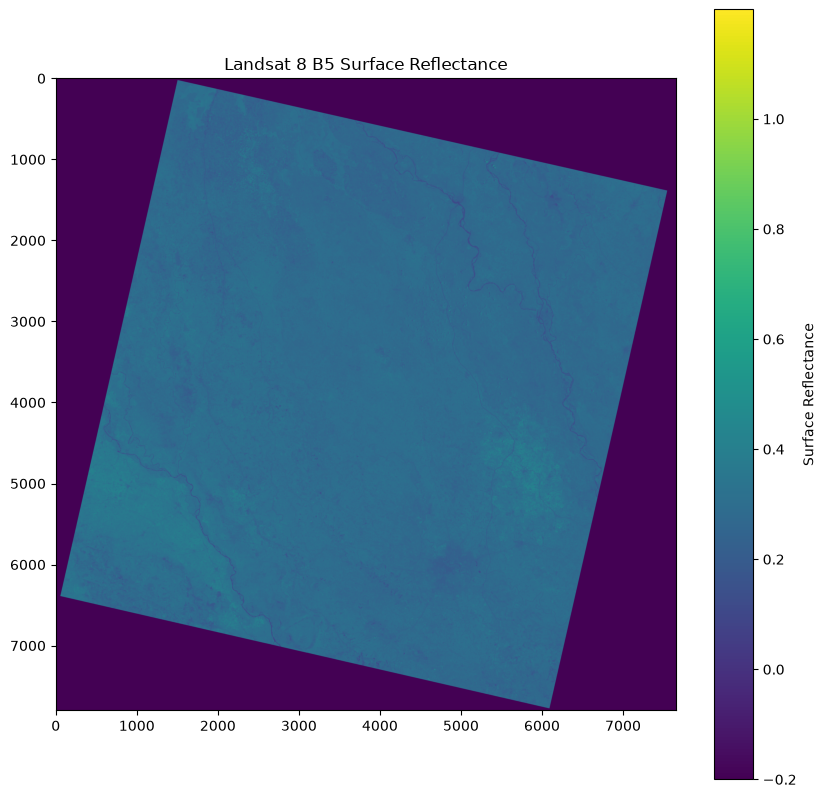

In [166]:
plt.figure(figsize=(10, 10))

plt.imshow(nir_reflectance)

plt.title("Landsat 8 B5 Surface Reflectance")
plt.colorbar(label="Surface Reflectance")

plt.show()

In [167]:
nir_lucknow_reflectance = (
    nir_lucknow.astype(np.float32) * nir_mult
    + nir_add
)

nir_lucknow_reflectance[nir_lucknow == 0] = np.nan

In [168]:
print("NIR minimum:", np.nanmin(nir_lucknow_reflectance))
print("NIR maximum:", np.nanmax(nir_lucknow_reflectance))
print("NIR mean:", np.nanmean(nir_lucknow_reflectance))

NIR minimum: 0.094854996
NIR maximum: 0.6753525
NIR mean: 0.25222194


Plotting the NIR Reflectance of Lucknow Area

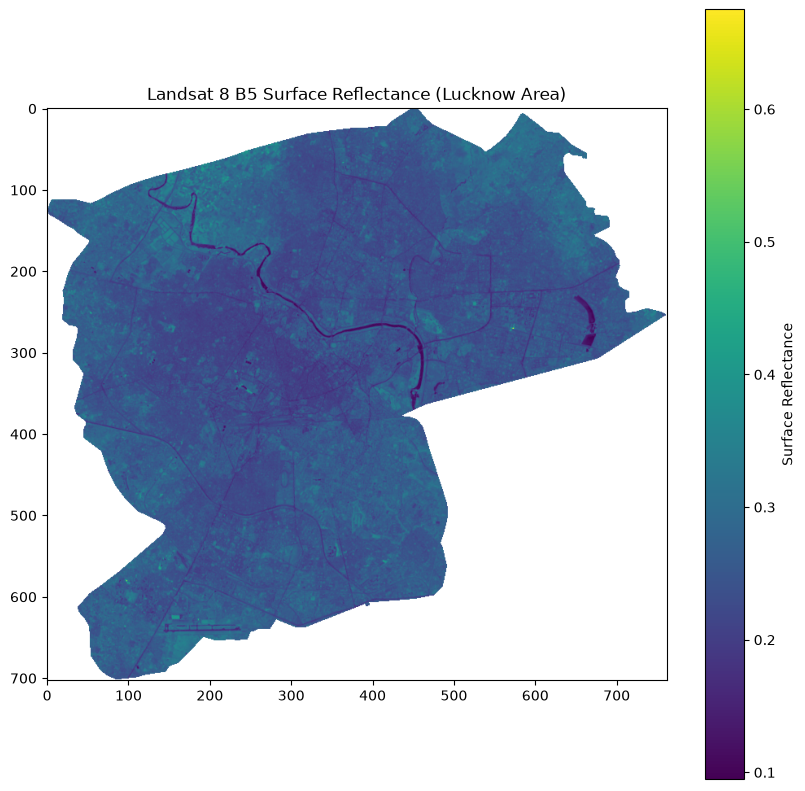

In [169]:
plt.figure(figsize=(10, 10))

plt.imshow(nir_lucknow_reflectance)

plt.title("Landsat 8 B5 Surface Reflectance (Lucknow Area)")
plt.colorbar(label="Surface Reflectance")

plt.show()

#### 9. Calculate the Normalized Difference Vegetation Index (NDVI).

In [170]:
denominator = (
    nir_lucknow_reflectance
    + red_lucknow_reflectance
)

ndvi = np.divide(
    nir_lucknow_reflectance - red_lucknow_reflectance,
    denominator,
    out=np.full_like(denominator, np.nan),
    where=denominator != 0
)

In [171]:
print("NDVI minimum:", np.nanmin(ndvi))
print("NDVI maximum:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))

NDVI minimum: 0.027113719
NDVI maximum: 0.77813345
NDVI mean: 0.30725604


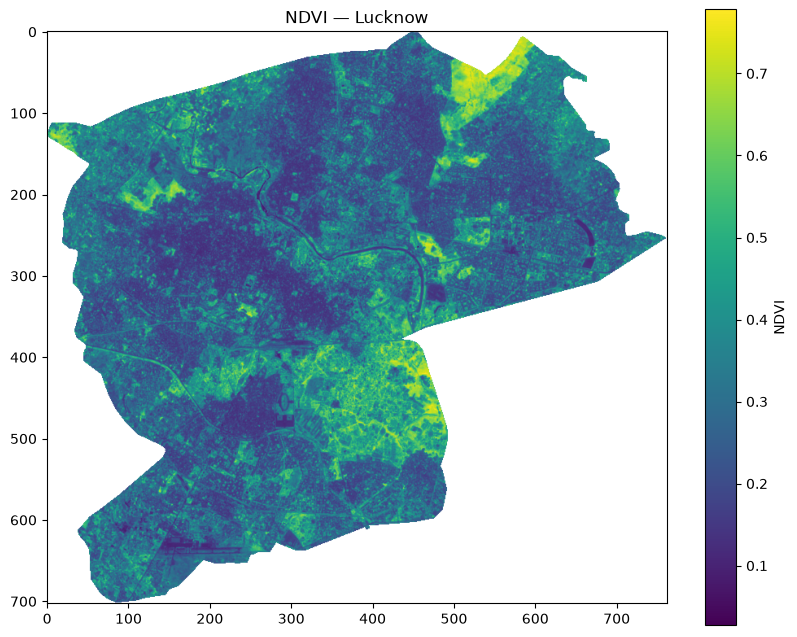

In [172]:
plt.figure(figsize=(10, 8))

plt.imshow(ndvi)

plt.title("NDVI — Lucknow")
plt.colorbar(label="NDVI")

plt.show()

## NDVI Results

The NDVI raster was generated for the Lucknow study area using Landsat 8
Level-2 surface reflectance from the Red (B4) and Near-Infrared (B5) bands.

Minimum NDVI: [0.027113719],
Maximum NDVI: [0.77813345],
Mean NDVI: [0.30725604]

The resulting spatial distribution shows variation in vegetation
conditions across the study area.

In [173]:
row = 400
col = 400


red_value = red_lucknow_reflectance[row, col]
nir_value = nir_lucknow_reflectance[row, col]
ndvi_value = ndvi[row, col]

print("Red:", red_value)
print("NIR:", nir_value)
print("NDVI:", ndvi_value)

Red: 0.08212249
NIR: 0.2553175
NDVI: 0.5132617


#### 10. Load the Landsat thermal Surface Temperature band (`ST_B10`).

In [174]:
st_files = list(landsat_folder.rglob("*_ST_B10.TIF"))

print(st_files)

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_ST_B10.TIF')]


In [175]:
st_path = st_files[0]

print("Using thermal band:", st_path.name)

Using thermal band: LC08_L2SP_144041_20260519_20260528_02_T1_ST_B10.TIF


In [176]:
with rasterio.open(st_path) as src:
    st = src.read(1)

    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: 0.0
Data type: uint16


In [177]:
valid_st = st[st != 0]

print("Valid pixels:", valid_st.size)
print("Minimum stored value:", valid_st.min())
print("Maximum stored value:", valid_st.max())
print("Mean stored value:", valid_st.mean())

Valid pixels: 40523305
Minimum stored value: 43908
Maximum stored value: 58546
Mean stored value: 47867.974436315104


#### 11. Extract the Level-2 Surface Temperature scaling parameters.

In [178]:
temperature_group = "LEVEL2_SURFACE_TEMPERATURE_PARAMETERS"

temperature_block = extract_mtl_group(
    mtl_text,
    temperature_group
)

temperature_params = parse_mtl_block(
    temperature_block
)

In [179]:
print(temperature_params)

{'TEMPERATURE_MAXIMUM_BAND_ST_B10': 372.999941, 'TEMPERATURE_MINIMUM_BAND_ST_B10': 149.003418, 'QUANTIZE_CAL_MAXIMUM_BAND_ST_B10': 65535.0, 'QUANTIZE_CAL_MINIMUM_BAND_ST_B10': 1.0, 'TEMPERATURE_MULT_BAND_ST_B10': 0.00341802, 'TEMPERATURE_ADD_BAND_ST_B10': 149.0}


In [180]:
for key, value in temperature_params.items():
    print(f"{key}: {value}")

TEMPERATURE_MAXIMUM_BAND_ST_B10: 372.999941
TEMPERATURE_MINIMUM_BAND_ST_B10: 149.003418
QUANTIZE_CAL_MAXIMUM_BAND_ST_B10: 65535.0
QUANTIZE_CAL_MINIMUM_BAND_ST_B10: 1.0
TEMPERATURE_MULT_BAND_ST_B10: 0.00341802
TEMPERATURE_ADD_BAND_ST_B10: 149.0


#### 12. Clip and convert the thermal data to Land Surface Temperature.

In [181]:
with rasterio.open(st_path) as src:
    st_lucknow, st_transform = mask(
        src,
        lucknow.geometry,
        crop=True,
        nodata=0
    )

st_lucknow = st_lucknow[0]

print("Original ST_B10:", st.shape)
print("Lucknow ST_B10:", st_lucknow.shape)

Original ST_B10: (7801, 7651)
Lucknow ST_B10: (703, 762)


In [182]:
temperature_mult = temperature_params["TEMPERATURE_MULT_BAND_ST_B10"]
temperature_add = temperature_params["TEMPERATURE_ADD_BAND_ST_B10"]

print("Temperature scale:", temperature_mult)
print("Temperature offset:", temperature_add)

Temperature scale: 0.00341802
Temperature offset: 149.0


In [183]:
lst_kelvin = (
    st_lucknow.astype(np.float32)
    * temperature_mult
    + temperature_add
)

In [184]:
lst_kelvin[st_lucknow == 0] = np.nan

#### 13. Convert temperature from Kelvin to degrees Celsius.

In [185]:
lst_celsius = lst_kelvin - 273.15

In [186]:
print("LST minimum:", np.nanmin(lst_celsius))
print("LST maximum:", np.nanmax(lst_celsius))
print("LST mean:", np.nanmean(lst_celsius))

LST minimum: 32.2381
LST maximum: 45.209473
LST mean: 39.17736


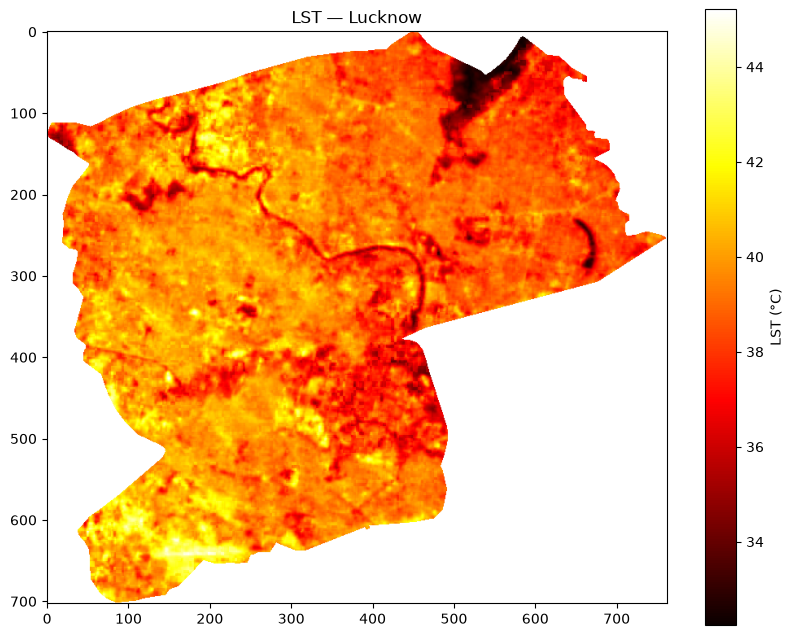

In [216]:
plt.figure(figsize=(10, 8))

plt.imshow(lst_celsius, cmap="hot")

plt.title("LST — Lucknow")
plt.colorbar(label="LST (°C)")

plt.show()

#### 14. Apply appropriate quality masking to remove invalid observations.

In [187]:
st_qa_files = list(landsat_folder.rglob("*_ST_QA.TIF"))

print(st_qa_files)

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_ST_QA.TIF')]


In [188]:
st_qa_path = st_qa_files[0]

print("Using:", st_qa_path.name)

Using: LC08_L2SP_144041_20260519_20260528_02_T1_ST_QA.TIF


In [189]:
with rasterio.open(st_qa_path) as src:
    st_qa = src.read(1)

    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: -9999.0
Data type: int16


In [190]:
valid_st_qa = st_qa[st_qa != -9999]

print("Valid ST_QA pixels:", valid_st_qa.size)
print("Minimum ST_QA:", valid_st_qa.min())
print("Maximum ST_QA:", valid_st_qa.max())
print("Mean ST_QA:", valid_st_qa.mean())

Valid ST_QA pixels: 40523305
Minimum ST_QA: 0
Maximum ST_QA: 9959
Mean ST_QA: 180.9133412736202


In [191]:
st_uncertainty = valid_st_qa * 0.01

print("Minimum uncertainty (K):", st_uncertainty.min())
print("Maximum uncertainty (K):", st_uncertainty.max())
print("Mean uncertainty (K):", st_uncertainty.mean())

Minimum uncertainty (K): 0.0
Maximum uncertainty (K): 99.59
Mean uncertainty (K): 1.8091334127362022


In [192]:
valid_st_qa = st_qa[st_qa != -9999]

print("Valid ST_QA pixels:", valid_st_qa.size)
print("Minimum ST_QA:", valid_st_qa.min())
print("Maximum ST_QA:", valid_st_qa.max())
print("Mean ST_QA:", valid_st_qa.mean())

st_uncertainty = valid_st_qa * 0.01

print("Minimum uncertainty (K):", st_uncertainty.min())
print("Maximum uncertainty (K):", st_uncertainty.max())
print("Mean uncertainty (K):", st_uncertainty.mean())

Valid ST_QA pixels: 40523305
Minimum ST_QA: 0
Maximum ST_QA: 9959
Mean ST_QA: 180.9133412736202
Minimum uncertainty (K): 0.0
Maximum uncertainty (K): 99.59
Mean uncertainty (K): 1.8091334127362022


In [193]:
qa_pixel_files = list(
    landsat_folder.rglob("*_QA_PIXEL.TIF")
)

print(qa_pixel_files)

[WindowsPath('d:/Projects/GeoAI-LST-Downscaling/data/raw/landsat/LC08_L2SP_144041_20260519_20260528_02_T1_QA_PIXEL.TIF')]


In [194]:
qa_pixel_path = qa_pixel_files[0]

print("Using:", qa_pixel_path.name)

Using: LC08_L2SP_144041_20260519_20260528_02_T1_QA_PIXEL.TIF


In [195]:
with rasterio.open(qa_pixel_path) as src:
    qa_pixel = src.read(1)

    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Data type:", src.dtypes[0])

Width: 7651
Height: 7801
CRS: EPSG:32644
Resolution: (30.0, 30.0)
NoData: None
Data type: uint16


In [196]:
cloud_flag = (qa_pixel >> 3) & 1

print("Cloud pixels:", np.sum(cloud_flag == 1))
print("Clear pixels:", np.sum(cloud_flag == 0))

Cloud pixels: 10656
Clear pixels: 59674795


In [197]:
total_pixels = qa_pixel.size

cloud_percentage = (
    np.sum(cloud_flag == 1)
    / total_pixels
    * 100
)

print("Cloud percentage:", cloud_percentage)

Cloud percentage: 0.017853597185686007


In [198]:
# Bit 0: Fill
fill_flag = (qa_pixel >> 0) & 1

# Bit 1: Dilated cloud
dilated_cloud_flag = (qa_pixel >> 1) & 1

# Bit 2: Cirrus
cirrus_flag = (qa_pixel >> 2) & 1

# Bit 3: Cloud
cloud_flag = (qa_pixel >> 3) & 1

# Bit 4: Cloud shadow
cloud_shadow_flag = (qa_pixel >> 4) & 1

# Bit 5: Snow
snow_flag = (qa_pixel >> 5) & 1


print("Fill pixels:", np.sum(fill_flag == 1))
print("Dilated cloud pixels:", np.sum(dilated_cloud_flag == 1))
print("Cirrus pixels:", np.sum(cirrus_flag == 1))
print("Cloud pixels:", np.sum(cloud_flag == 1))
print("Cloud shadow pixels:", np.sum(cloud_shadow_flag == 1))
print("Snow pixels:", np.sum(snow_flag == 1))

Fill pixels: 19161338
Dilated cloud pixels: 17685
Cirrus pixels: 20
Cloud pixels: 10656
Cloud shadow pixels: 18249
Snow pixels: 0


In [199]:
valid_qa_mask = (
    (fill_flag == 0) &
    (dilated_cloud_flag == 0) &
    (cirrus_flag == 0) &
    (cloud_flag == 0) &
    (cloud_shadow_flag == 0) &
    (snow_flag == 0)
)

In [200]:
print("Total pixels:", qa_pixel.size)
print("Valid pixels:", np.sum(valid_qa_mask))
print("Masked pixels:", np.sum(~valid_qa_mask))

valid_percentage = (
    np.sum(valid_qa_mask) / qa_pixel.size * 100
)

print("Valid percentage:", valid_percentage)

Total pixels: 59685451
Valid pixels: 40488609
Masked pixels: 19196842
Valid percentage: 67.83664749387586


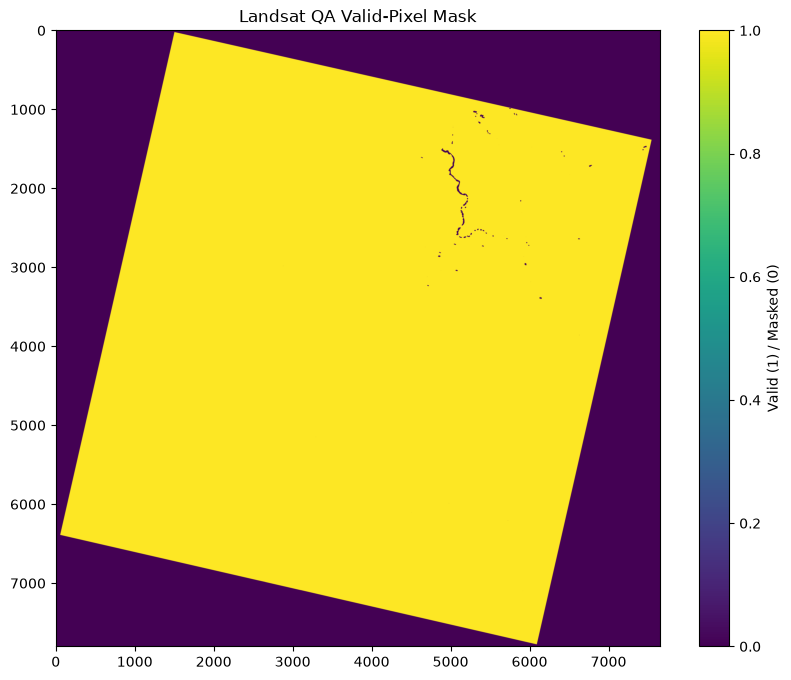

In [201]:
plt.figure(figsize=(10, 8))

plt.imshow(valid_qa_mask)

plt.title("Landsat QA Valid-Pixel Mask")
plt.colorbar(label="Valid (1) / Masked (0)")

plt.show()

In [202]:
with rasterio.open(qa_pixel_path) as src:
    qa_lucknow, qa_transform = mask(
        src,
        lucknow.geometry,
        crop=True,
        nodata=0
    )

qa_lucknow = qa_lucknow[0]

print("Lucknow QA shape:", qa_lucknow.shape)

Lucknow QA shape: (703, 762)


In [203]:
fill_lucknow = (qa_lucknow >> 0) & 1
dilated_cloud_lucknow = (qa_lucknow >> 1) & 1
cirrus_lucknow = (qa_lucknow >> 2) & 1
cloud_lucknow = (qa_lucknow >> 3) & 1
cloud_shadow_lucknow = (qa_lucknow >> 4) & 1
snow_lucknow = (qa_lucknow >> 5) & 1

In [204]:
qa_mask_lucknow = (
    (fill_lucknow == 0) &
    (dilated_cloud_lucknow == 0) &
    (cirrus_lucknow == 0) &
    (cloud_lucknow == 0) &
    (cloud_shadow_lucknow == 0) &
    (snow_lucknow == 0)
)

In [205]:
print("Total Lucknow pixels:", qa_lucknow.size)
print("Valid Lucknow pixels:", np.sum(qa_mask_lucknow))
print("Masked Lucknow pixels:", np.sum(~qa_mask_lucknow))

print(
    "Valid Lucknow percentage:",
    np.sum(qa_mask_lucknow) / qa_lucknow.size * 100
)

Total Lucknow pixels: 535686
Valid Lucknow pixels: 535682
Masked Lucknow pixels: 4
Valid Lucknow percentage: 99.99925329390726


In [206]:
print("LST shape:", lst_celsius.shape)
print("QA mask shape:", qa_mask_lucknow.shape)

LST shape: (703, 762)
QA mask shape: (703, 762)


In [207]:
lst_qa_masked = lst_celsius.copy()

lst_qa_masked[~qa_mask_lucknow] = np.nan

In [208]:
print("LST minimum:", np.nanmin(lst_qa_masked))
print("LST maximum:", np.nanmax(lst_qa_masked))
print("LST mean:", np.nanmean(lst_qa_masked))

LST minimum: 32.2381
LST maximum: 45.209473
LST mean: 39.177376


In [209]:
with rasterio.open(st_qa_path) as src:
    st_qa_lucknow, st_qa_transform = mask(
        src,
        lucknow.geometry,
        crop=True,
        nodata=-9999
    )

st_qa_lucknow = st_qa_lucknow[0]

print("Lucknow ST_QA shape:", st_qa_lucknow.shape)

Lucknow ST_QA shape: (703, 762)


In [210]:
print("Minimum:", st_qa_lucknow.min())
print("Maximum:", st_qa_lucknow.max())
print("Mean:", st_qa_lucknow[st_qa_lucknow != -9999].mean())

Minimum: -9999
Maximum: 510
Mean: 168.02767958380576


In [211]:
valid_st_qa_lucknow = st_qa_lucknow[
    st_qa_lucknow != -9999
]

st_uncertainty_lucknow = (
    valid_st_qa_lucknow * 0.01
)

print(
    "Minimum uncertainty (K):",
    np.min(st_uncertainty_lucknow)
)

print(
    "Maximum uncertainty (K):",
    np.max(st_uncertainty_lucknow)
)

print(
    "Mean uncertainty (K):",
    np.mean(st_uncertainty_lucknow)
)

Minimum uncertainty (K): 1.53
Maximum uncertainty (K): 5.1000000000000005
Mean uncertainty (K): 1.680276795838058


In [212]:
percentiles = np.percentile(
    st_uncertainty_lucknow,
    [50, 75, 90, 95, 99]
)

print("50th percentile:", percentiles[0])
print("75th percentile:", percentiles[1])
print("90th percentile:", percentiles[2])
print("95th percentile:", percentiles[3])
print("99th percentile:", percentiles[4])

50th percentile: 1.6300000000000001
75th percentile: 1.71
90th percentile: 1.84
95th percentile: 1.96
99th percentile: 2.3000000000000003


In [213]:
st_uncertainty_lucknow = (
    st_qa_lucknow.astype(np.float32) * 0.01
)

st_qa_mask_lucknow = (
    (st_qa_lucknow != -9999) &
    (st_uncertainty_lucknow < 3.0)
)

In [214]:
print(
    "Valid ST_QA pixels:",
    np.sum(st_qa_mask_lucknow)
)

print(
    "Rejected ST_QA pixels:",
    np.sum(~st_qa_mask_lucknow)
)

print(
    "Valid percentage:",
    np.sum(st_qa_mask_lucknow)
    / st_qa_mask_lucknow.size
    * 100
)

Valid ST_QA pixels: 314652
Rejected ST_QA pixels: 221034
Valid percentage: 58.738141373864536


In [215]:
print("Uncertainty < 2 K:",
      np.sum(st_uncertainty_lucknow < 2.0))

print("Uncertainty 2–3 K:",
      np.sum(
          (st_uncertainty_lucknow >= 2.0) &
          (st_uncertainty_lucknow < 3.0)
      ))

print("Uncertainty 3–4 K:",
      np.sum(
          (st_uncertainty_lucknow >= 3.0) &
          (st_uncertainty_lucknow < 4.0)
      ))

print("Uncertainty 4–5 K:",
      np.sum(
          (st_uncertainty_lucknow >= 4.0) &
          (st_uncertainty_lucknow < 5.0)
      ))

print("Uncertainty >= 5 K:",
      np.sum(st_uncertainty_lucknow >= 5.0))

Uncertainty < 2 K: 522890
Uncertainty 2–3 K: 12595
Uncertainty 3–4 K: 164
Uncertainty 4–5 K: 21
Uncertainty >= 5 K: 16


#### 15. Visualize and validate the resulting LST and NDVI rasters.